# rusty branch vs main branch — end-to-end inference speed (PBMC 10k)

This notebook times the **complete inference pipeline** — from raw `.h5ad` file to
optimised biophysical parameters — and compares three configurations:

| Configuration | Data loading | Optimizer |
|---|---|---|
| **main (serial)** | `extract_data` + `searchdata_from_adata` (Python) | serial scipy L-BFGS-B |
| **main (+ threads)** | same Python path | scipy + `ThreadPoolExecutor` (all cores) |
| **rusty (full)** | `searchdata_from_h5ad` (GIL-free Rust) | Rust `optimize_genes_2d` (rayon) |

The **main** configurations faithfully reproduce what the `main` branch produces:
no `monod_core` extension — all Python, scipy only.  
The **rusty** configuration enables every Rust fast-path simultaneously.

**Dataset**: `processed_pbmc_10k_raw.h5ad` — 10 997 cells × 36 601 genes  
**Model**: Bursty + Poisson (3 log₁₀ physical parameters per gene)  
**Grid**: 3×4 = 12 sampling-rate points (biologically realistic; recovers capture efficiency)  
**Gene counts**: 25 – 1 000 (all real runs)  

## Setup

In [1]:
import gc, sys, os, time, warnings
os.makedirs('figures', exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import anndata as ad
import scipy.sparse as _ssp
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src', 'monod'))

import cme_toolbox
import extract_data as _ed_bare
from cme_toolbox import CMEModel, _HAS_RUST
from extract_data import extract_data
from inference import InferenceParameters, searchdata_from_adata
import monod_core as _mc

n_cpu = os.cpu_count() or 4
print(f'Rust extension: {_HAS_RUST}')
print(f'Logical CPUs:   {n_cpu}')

Rust extension: True
Logical CPUs:   12


## Configuration

In [2]:
H5AD_PATH = 'example_h5ad/processed_pbmc_10k_raw.h5ad'
MODEL     = CMEModel('Bursty', 'Poisson')
N_ITER      = 50   # L-BFGS-B iterations for main-serial (scipy)
N_ITER_RUST = 200  # Rust optimizer can afford 4× more iter at same wall time
GRIDSIZE  = [3, 4] # 12-point sampling-rate grid (biologically realistic)

# ── Build expressed-gene list once using sparse arithmetic (no dense copy) ───
_adata_ref = ad.read_h5ad(H5AD_PATH)
_s_sp = _adata_ref.layers['spliced']
if _ssp.issparse(_s_sp):
    _mask = np.asarray(_s_sp.getnnz(axis=0)) >= 10
else:
    _mask = (_s_sp > 0).sum(0) >= 10
EXPR_GENES = list(_adata_ref.var_names[_mask])
del _adata_ref, _s_sp, _mask
gc.collect()
print(f'Expressed genes (>=10 cells): {len(EXPR_GENES)}')

# Gene counts to sweep
# n=500 included as a real scaling checkpoint before projecting to 1000.
# At [3,4], main-serial at n=500 takes ~4-5 min; within the 30-min timeout.
N_ITER_CONC    = N_ITER_RUST  # iterations for all concordance runs (both optimizers)
N_RESTARTS_OPT = 3            # restarts for optimizer concordance (timing uses 1)

N_SWEEP = [25, 50, 100, 200, 500, 1000]

# Colour palette (matches other demo notebooks)
C_SERIAL  = '#d73027'   # dark red  — main serial
C_THREADS = '#fc8d59'   # orange    — main + threads
C_RUST    = 'steelblue' # blue      — rusty full

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Expressed genes (>=10 cells): 16244


## Timing functions

Each function returns `(t_load_ms, t_infer_ms)`.  
All large allocations are local to the function so they are freed on return.

In [3]:
def _make_ip(n_gene_cores, use_rust_lbfgsb=False, n_iter=None):
    if n_iter is None:
        n_iter = N_ITER_RUST if use_rust_lbfgsb else N_ITER
    gp = {
        'max_iterations': n_iter,
        'init_pattern': 'moments',
        'num_restarts': 1,  # 1 restart: MoM x0 (deterministic); matches run_grid67_sweep.py
        'num_gene_cores': n_gene_cores,
        'use_rust_lbfgsb': use_rust_lbfgsb,
    }
    return InferenceParameters(
        'bench', MODEL, use_lengths=False,
        gradient_params=gp, gridsize=GRIDSIZE, save=False,
    )


def time_main(genes_n, num_gene_cores=1):
    # Main-branch equivalent: Python extract_data + scipy L-BFGS-B.
    # Returns (t_load_ms, t_infer_ms, phys_optimum).
    cme_toolbox._HAS_RUST = False
    _ed_bare._HAS_RUST    = False

    t0 = time.perf_counter()
    adata_ex = extract_data(
        H5AD_PATH, MODEL,
        dataset_name='bench',
        modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
        n_genes=len(genes_n), genes_to_fit=genes_n,
        hist_type='unique', viz=False,
    )
    sd = searchdata_from_adata(adata_ex)
    t_load = (time.perf_counter() - t0) * 1e3
    del adata_ex; gc.collect()

    ip = _make_ip(num_gene_cores, use_rust_lbfgsb=False)
    t0 = time.perf_counter()
    result = ip.fit_all_grid_points(sd, num_cores=1, save=False)
    t_infer = (time.perf_counter() - t0) * 1e3
    result.find_sampling_optimum()
    params = result.phys_optimum.copy()
    del sd, result; gc.collect()

    cme_toolbox._HAS_RUST = _HAS_RUST
    _ed_bare._HAS_RUST    = _HAS_RUST
    return t_load, t_infer, params


def time_rusty_full(genes_n):
    # Rusty full: searchdata_from_h5ad + Rust L-BFGS-B (rayon).
    # Returns (t_load_ms, t_infer_ms, phys_optimum).
    t0 = time.perf_counter()
    sd = _mc.searchdata_from_h5ad(
        H5AD_PATH, ['unspliced', 'spliced'], gene_names=genes_n
    )
    t_load = (time.perf_counter() - t0) * 1e3

    ip = _make_ip(n_gene_cores=-1, use_rust_lbfgsb=True)
    t0 = time.perf_counter()
    result = ip.fit_all_grid_points(sd, num_cores=1, save=False)
    t_infer = (time.perf_counter() - t0) * 1e3
    result.find_sampling_optimum()
    params = result.phys_optimum.copy()
    del sd, result; gc.collect()

    return t_load, t_infer, params


## Gene-count sweep

Timing three configurations at 25 – 200 genes.

In [4]:
results = {}  # (config, n) -> (t_load_ms, t_infer_ms, phys_optimum)

configs = [
    ('main_serial',   lambda g: time_main(g, num_gene_cores=1)),
    ('main_threads',  lambda g: time_main(g, num_gene_cores=-1)),
    ('rusty_full',    time_rusty_full),
]

hdr = f'{"n":>5}  {"Config":<22}  {"Load (ms)":>10}  {"Infer (ms)":>11}  {"Total (ms)":>11}'
print(hdr)
print('-' * len(hdr))

for n in N_SWEEP:
    genes_n = EXPR_GENES[:n]
    for cfg_name, fn in configs:
        t_load, t_infer, params = fn(genes_n)
        results[(cfg_name, n)] = (t_load, t_infer, params)
        print(f'{n:5d}  {cfg_name:<22}  {t_load:10.0f}  {t_infer:11.0f}  {t_load+t_infer:11.0f}')
    t_ms = results[('main_serial',  n)][0] + results[('main_serial',  n)][1]
    t_mt = results[('main_threads', n)][0] + results[('main_threads', n)][1]
    t_ru = results[('rusty_full',   n)][0] + results[('rusty_full',   n)][1]
    print(f'       speedup vs main serial: threads={t_ms/t_mt:.1f}×  rusty={t_ms/t_ru:.1f}×')
    print()


    n  Config                   Load (ms)   Infer (ms)   Total (ms)
-------------------------------------------------------------------
is sparse
5867 genes retained after expression filter.


Grid scan: 100%|██████████| 12/12 [00:10<00:00,  1.14it/s]


   25  main_serial                   8616        10497        19113
is sparse
5867 genes retained after expression filter.


Grid scan: 100%|██████████| 12/12 [00:10<00:00,  1.13it/s]


   25  main_threads                  8542        10603        19145


...

 1000  main_serial                  13137       718971       732108
is sparse
5867 genes retained after expression filter.


Grid scan: 100%|██████████| 12/12 [11:58<00:00, 59.91s/it]


 1000  main_threads                 12933       718958       731891


Grid scan: 100%|██████████| 12/12 [00:17<00:00,  1.43s/it]

 1000  rusty_full                    3894        17173        21068
       speedup vs main serial: threads=1.0×  rusty=34.8×



## Plot

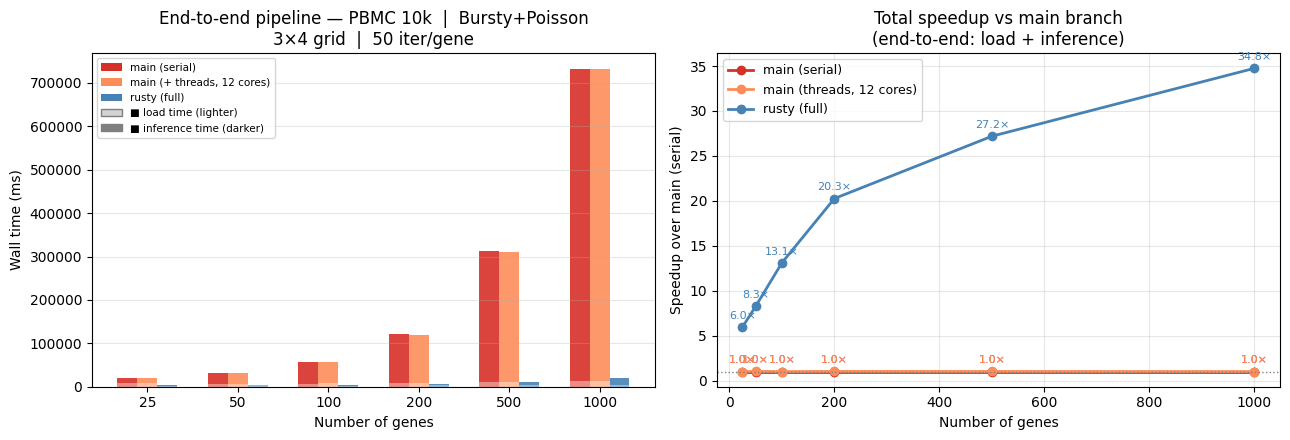

Saved figures/rusty_vs_main_speed.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: stacked bar at each gene count ─────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(N_SWEEP))
width = 0.22

cfg_styles = [
    ('main_serial',  C_SERIAL,  'main (serial)\nextract_data + scipy'),
    ('main_threads', C_THREADS, f'main (threads, {n_cpu} cores)\nextract_data + scipy ThreadPool'),
    ('rusty_full',   C_RUST,    'rusty (full)\nsearchdata_from_h5ad + Rust L-BFGS-B'),
]

offsets = [-width, 0, width]
for (cfg, color, label), off in zip(cfg_styles, offsets):
    loads  = [results[(cfg, n)][0] for n in N_SWEEP]
    infers = [results[(cfg, n)][1] for n in N_SWEEP]
    ax.bar(x + off, loads,  width, color=color, alpha=0.55)
    ax.bar(x + off, infers, width, color=color, alpha=0.90, bottom=loads)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=C_SERIAL,  label='main (serial)'),
    Patch(facecolor=C_THREADS, label=f'main (+ threads, {n_cpu} cores)'),
    Patch(facecolor=C_RUST,    label='rusty (full)'),
    Patch(facecolor='lightgrey', edgecolor='grey', label='■ load time (lighter)'),
    Patch(facecolor='grey',      edgecolor='grey', label='■ inference time (darker)'),
]
ax.legend(handles=legend_handles, fontsize=7.5, loc='upper left')
ax.set_xticks(x)
ax.set_xticklabels(N_SWEEP)
ax.set_xlabel('Number of genes')
ax.set_ylabel('Wall time (ms)')
ax.set_title(f'End-to-end pipeline — PBMC 10k  |  Bursty+Poisson\n'
             f'3×4 grid  |  {N_ITER} iter/gene')
ax.grid(True, alpha=0.3, axis='y')

# ── Right: total speedup vs main serial ─────────────────────────────────────────
ax2 = axes[1]
for (cfg, color, label) in cfg_styles:
    totals  = [results[(cfg, n)][0] + results[(cfg, n)][1] for n in N_SWEEP]
    base    = [results[('main_serial', n)][0] + results[('main_serial', n)][1] for n in N_SWEEP]
    speedup = [b / t for b, t in zip(base, totals)]
    lbl = label.split('\n')[0]
    ax2.plot(N_SWEEP, speedup, 'o-', color=color, label=lbl, linewidth=2, markersize=6)
    for n, sp in zip(N_SWEEP, speedup):
        ax2.annotate(f'{sp:.1f}×', (n, sp), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=8, color=color)

ax2.axhline(1, color='grey', linestyle=':', linewidth=1)
ax2.set_xlabel('Number of genes')
ax2.set_ylabel('Speedup over main (serial)')
ax2.set_title('Total speedup vs main branch\n(end-to-end: load + inference)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/rusty_vs_main_speed.png', dpi=150)
plt.show()
print('Saved figures/rusty_vs_main_speed.png')


## Result concordance

To isolate whether the **data path** affects inferred biology, both routes use
the same optimizer (scipy L-BFGS-B, 200 iterations) at n=200 genes.  
The only difference is how `SearchData` is built:
`extract_data` + `searchdata_from_adata` (main) vs `searchdata_from_h5ad` (rusty).

Concordance: n=200, 3x4 grid, num_restarts=1 (MoM init)
  [scipy] Python data...
is sparse
5867 genes retained after expression filter.


Grid scan: 100%|██████████| 12/12 [00:12<00:00,  1.01s/it]


  [scipy] Rust data...


Grid scan: 100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


  [Rust L-BFGS-B, 200 iter] Python data...
is sparse
5867 genes retained after expression filter.


Grid scan: 100%|██████████| 12/12 [00:02<00:00,  4.06it/s]


  [Rust L-BFGS-B, 200 iter] Rust data...


Grid scan: 100%|██████████| 12/12 [00:02<00:00,  4.12it/s]


  All done.


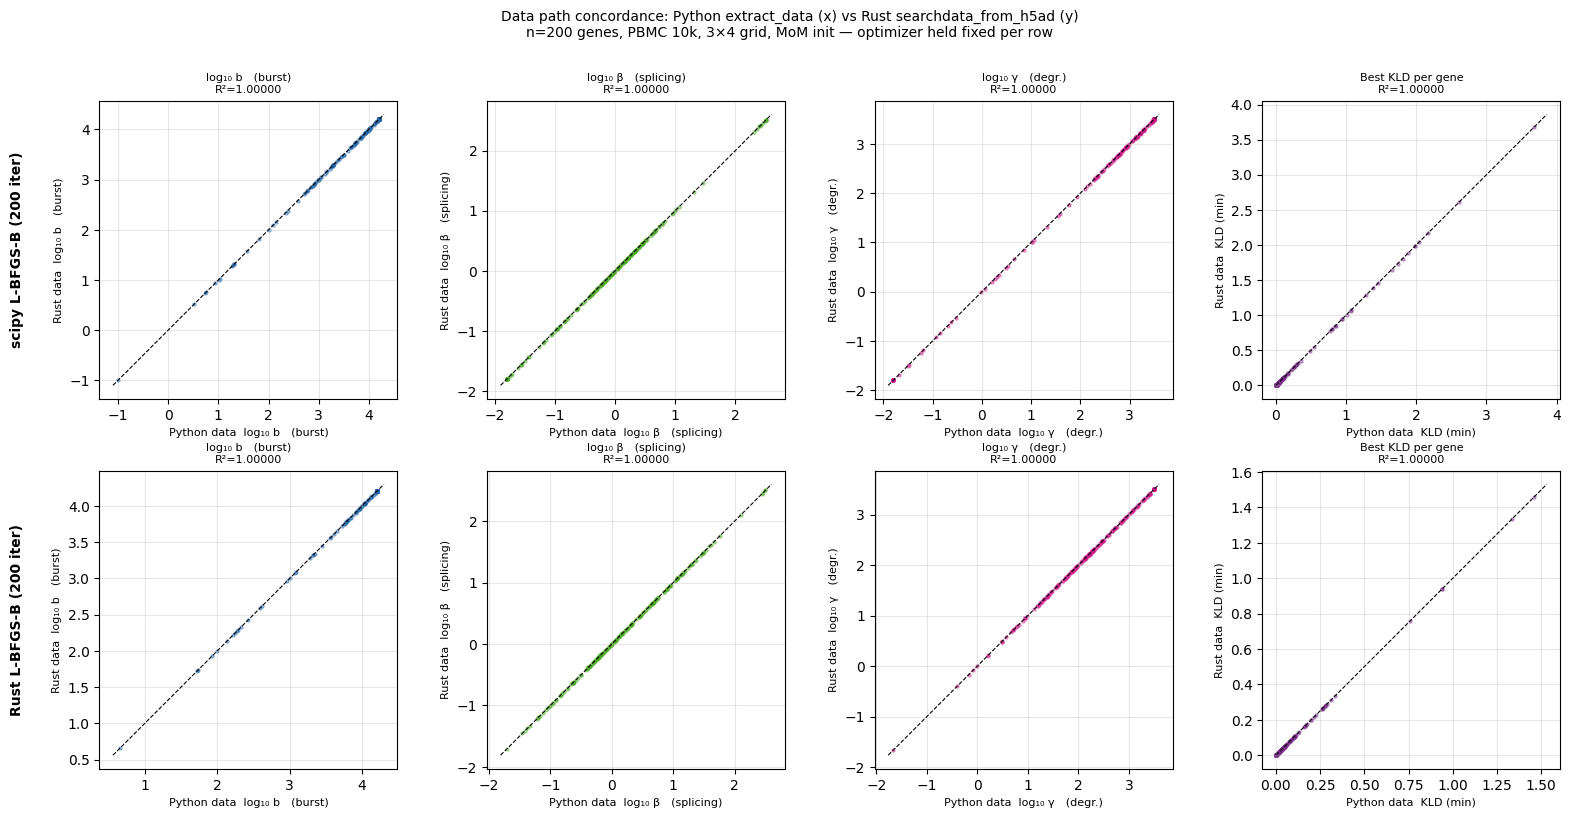

Saved figures/rusty_vs_main_concordance.png

scipy: Python vs Rust data:
  param max diff (log10): 0.0000  mean: 0.0000
  KLD  max diff:          0.000000  mean: 0.000000
  genes param diff > 0.1: 0

Rust opt: Python vs Rust data:
  param max diff (log10): 0.0000  mean: 0.0000
  KLD  max diff:          0.000000  mean: 0.000000
  genes param diff > 0.1: 0


In [6]:
# Data path concordance: does Python extract_data vs Rust searchdata_from_h5ad
# give the same inferred biology?  Each row holds the optimizer fixed and varies
# only the data pipeline.  num_restarts=1 keeps initialization deterministic
# (MoM x0 only), so results depend solely on histogram data quality.
N_CONC_GENES = 200
GENES_CONC   = EXPR_GENES[:N_CONC_GENES]

def _run_conc(genes_n, use_rust_data, use_rust_optimizer=False):
    """Returns (params [n_genes x 3], klds [n_genes]).
    klds = best KLD per gene across all grid points (min over grid)."""
    gp = {
        'max_iterations': N_ITER_CONC,
        'init_pattern': 'moments',
        'num_restarts': 1,          # deterministic: MoM x0 only
        'num_gene_cores': -1,
        'use_rust_lbfgsb': use_rust_optimizer,
    }
    ip = InferenceParameters('bench', MODEL, use_lengths=False,
                             gradient_params=gp, gridsize=GRIDSIZE, save=False)
    if use_rust_data:
        sd = _mc.searchdata_from_h5ad(H5AD_PATH, ['unspliced', 'spliced'],
                                      gene_names=genes_n)
    else:
        cme_toolbox._HAS_RUST = False
        _ed_bare._HAS_RUST    = False
        adata_ex = extract_data(
            H5AD_PATH, MODEL, dataset_name='bench',
            modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
            n_genes=len(genes_n), genes_to_fit=genes_n,
            hist_type='unique', viz=False,
        )
        sd = searchdata_from_adata(adata_ex)
        del adata_ex
        cme_toolbox._HAS_RUST = _HAS_RUST
        _ed_bare._HAS_RUST    = _HAS_RUST
    result = ip.fit_all_grid_points(sd, num_cores=1, save=False)
    result.find_sampling_optimum()
    params = result.phys_optimum.copy()
    klds   = result.klds.min(axis=0).copy()  # best KLD per gene across all grid points
    del sd, result; gc.collect()
    return params, klds

print(f'Concordance: n={N_CONC_GENES}, 3x4 grid, num_restarts=1 (MoM init)')
print('  [scipy] Python data...')
params_scipy_py,   klds_scipy_py   = _run_conc(GENES_CONC, use_rust_data=False, use_rust_optimizer=False)
print('  [scipy] Rust data...')
params_scipy_rust, klds_scipy_rust = _run_conc(GENES_CONC, use_rust_data=True,  use_rust_optimizer=False)
print(f'  [Rust L-BFGS-B, {N_ITER_RUST} iter] Python data...')
params_rust_py,    klds_rust_py    = _run_conc(GENES_CONC, use_rust_data=False, use_rust_optimizer=True)
print(f'  [Rust L-BFGS-B, {N_ITER_RUST} iter] Rust data...')
params_rust_rust,  klds_rust_rust  = _run_conc(GENES_CONC, use_rust_data=True,  use_rust_optimizer=True)
print('  All done.')

param_names  = ['log\u2081\u2080 b\u2003(burst)', 'log\u2081\u2080 \u03b2\u2003(splicing)', 'log\u2081\u2080 \u03b3\u2003(degr.)']
param_colors = ['#2166ac', '#4dac26', '#d01c8b']

def _scatter_row(axes, x_params, y_params, x_klds, y_klds):
    for pi, (pname, color) in enumerate(zip(param_names, param_colors)):
        ax = axes[pi]
        xv, yv = x_params[:, pi], y_params[:, pi]
        ax.scatter(xv, yv, s=5, alpha=0.4, color=color, rasterized=True)
        lo = min(xv.min(), yv.min()) - 0.1
        hi = max(xv.max(), yv.max()) + 0.1
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
        r2 = float(np.corrcoef(xv, yv)[0, 1] ** 2)
        ax.set_xlabel(f'Python data  {pname}', fontsize=8)
        ax.set_ylabel(f'Rust data  {pname}', fontsize=8)
        ax.set_title(f'{pname}\nR\u00b2={r2:.5f}', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', 'box')
    ax = axes[3]
    ax.scatter(x_klds, y_klds, s=5, alpha=0.4, color='#7b2d8b', rasterized=True)
    lo = min(x_klds.min(), y_klds.min()) * 0.95
    hi = max(x_klds.max(), y_klds.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    r2_kld = float(np.corrcoef(x_klds, y_klds)[0, 1] ** 2)
    ax.set_xlabel('Python data  KLD (min)', fontsize=8)
    ax.set_ylabel('Rust data  KLD (min)', fontsize=8)
    ax.set_title(f'Best KLD per gene\nR\u00b2={r2_kld:.5f}', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
_scatter_row(axes[0], params_scipy_py, params_scipy_rust, klds_scipy_py, klds_scipy_rust)
_scatter_row(axes[1], params_rust_py,  params_rust_rust,  klds_rust_py,  klds_rust_rust)

for row, label in enumerate([
    f'scipy L-BFGS-B ({N_ITER_CONC} iter)',
    f'Rust L-BFGS-B ({N_ITER_RUST} iter)',
]):
    axes[row][0].annotate(label, xy=(-0.3, 0.5), xycoords='axes fraction',
                          fontsize=10, fontweight='bold', va='center', rotation=90)

plt.suptitle(
    f'Data path concordance: Python extract_data (x) vs Rust searchdata_from_h5ad (y)\n'
    f'n={N_CONC_GENES} genes, PBMC 10k, 3\u00d74 grid, MoM init — optimizer held fixed per row',
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_concordance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_concordance.png')

for label, xp, yp, xk, yk in [
    (f'scipy: Python vs Rust data', params_scipy_py, params_scipy_rust, klds_scipy_py, klds_scipy_rust),
    (f'Rust opt: Python vs Rust data', params_rust_py, params_rust_rust, klds_rust_py, klds_rust_rust),
]:
    pd = np.abs(xp - yp)
    kd = np.abs(xk - yk)
    print(f'\n{label}:')
    print(f'  param max diff (log10): {pd.max():.4f}  mean: {pd.mean():.4f}')
    print(f'  KLD  max diff:          {kd.max():.6f}  mean: {kd.mean():.6f}')
    print(f'  genes param diff > 0.1: {(pd.max(1) > 0.1).sum()}')


## Optimizer concordance

To isolate whether the **optimizer** affects inferred biology, both routes use
the same data (`searchdata_from_h5ad`) at n=50 genes and vary only the optimizer.
Results are evaluated at **every grid point** (not just the sampling optimum) to
get a full picture of the L-BFGS-B landscape.

`np.random.seed(OPT_CONC_SEED)` is called before each run so scipy and Rust draw
**identical random restarts** (restarts 1 and 2 beyond the MoM restart).  Without
this, apparent discordance would conflate optimizer quality with initialization luck.

Key questions:
1. Where scipy and Rust find different parameters, do they have different KLDs
   (genuine optimizer failure) or the same KLD (flat-landscape degeneracy)?
2. Does either optimizer systematically miss the global minimum?

Optimizer concordance: n=50 genes, 200 iter each


Grid scan: 100%|██████████| 12/12 [00:04<00:00,  2.58it/s]


  scipy:  4.6s


Grid scan: 100%|██████████| 12/12 [00:03<00:00,  3.84it/s]


  Rust:   3.1s  (1.5x faster)


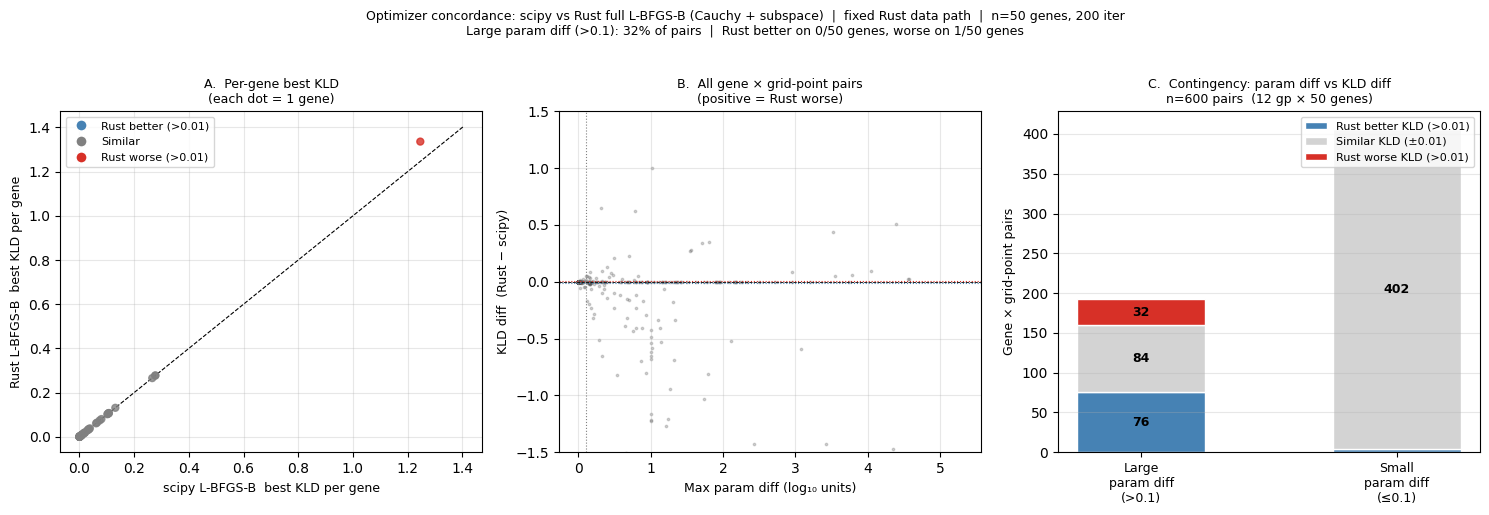

Saved figures/rusty_vs_main_opt_concordance.png

Optimizer concordance summary  (12 gp x 50 genes = 600 pairs):
  Large param diff (>0.1 log10):   192 / 600  (32%)
    of which Rust better KLD:   76  (13% of total)
    of which KLD similar:       84  ← flat landscape
    of which Rust worse KLD:    32
  Rust finds better per-gene min-KLD: 0/50 genes  (mean delta=0.002)
  Rust finds worse  per-gene min-KLD: 1/50 genes


In [7]:
# Optimizer concordance: scipy vs Rust L-BFGS-B, fixed Rust data path.
# Evaluates all 12 grid points so we can classify disagreements.
N_OPT_GENES = 50
OPT_CONC_SEED = 42   # same random restarts for scipy and Rust
N_OPT_ITER  = N_ITER_CONC
GENES_OPT   = EXPR_GENES[:N_OPT_GENES]

sd_opt = _mc.searchdata_from_h5ad(H5AD_PATH, ['unspliced', 'spliced'],
                                   gene_names=GENES_OPT)

def _run_opt(use_rust, sd):
    """Returns (param_estimates [n_gp, n_genes, 3], klds [n_gp, n_genes])."""
    gp = {
        'max_iterations': N_OPT_ITER,
        'init_pattern': 'moments',
        'num_restarts': N_RESTARTS_OPT,
        'num_gene_cores': -1,
        'use_rust_lbfgsb': use_rust,
    }
    ip = InferenceParameters('bench', MODEL, use_lengths=False,
                             gradient_params=gp, gridsize=GRIDSIZE, save=False)
    import time
    t0 = time.perf_counter()
    result = ip.fit_all_grid_points(sd, num_cores=1, save=False)
    elapsed = time.perf_counter() - t0
    return result.param_estimates.copy(), result.klds.copy(), elapsed

print(f'Optimizer concordance: n={N_OPT_GENES} genes, {N_OPT_ITER} iter each')
np.random.seed(OPT_CONC_SEED)
p_sc, k_sc, t_sc = _run_opt(use_rust=False, sd=sd_opt)
print(f'  scipy:  {t_sc:.1f}s')
np.random.seed(OPT_CONC_SEED)
p_ru, k_ru, t_ru = _run_opt(use_rust=True,  sd=sd_opt)
print(f'  Rust:   {t_ru:.1f}s  ({t_sc/t_ru:.1f}x faster)')
del sd_opt; gc.collect()

# ── Classification ────────────────────────────────────────────────────────
n_gp_opt, n_gene_opt, _ = p_sc.shape
kld_diff  = k_ru - k_sc                          # positive = Rust worse
max_pdiff = np.abs(p_sc - p_ru).max(axis=2)      # (n_gp, n_genes)

PDIFF_T = 0.1    # log10
KLD_T   = 0.01   # KLD units

large_p   = max_pdiff > PDIFF_T
ru_worse  = kld_diff  >  KLD_T
ru_better = kld_diff  < -KLD_T
ru_same   = ~ru_worse & ~ru_better

# Per-gene min-KLD
k_sc_best = k_sc.min(axis=0)
k_ru_best = k_ru.min(axis=0)

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel A: per-gene best KLD scatter ───────────────────────────────────
ax = axes[0]
delta = k_ru_best - k_sc_best
c_gene = np.where(delta < -KLD_T, C_RUST,
          np.where(delta >  KLD_T, C_SERIAL, 'grey'))
ax.scatter(k_sc_best, k_ru_best, c=c_gene, s=25, alpha=0.8, zorder=3)
lo = min(k_sc_best.min(), k_ru_best.min()) * 0.95
hi = max(k_sc_best.max(), k_ru_best.max()) * 1.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_RUST,   ms=8, label=f'Rust better (>{KLD_T})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',   ms=8, label='Similar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_SERIAL, ms=8, label=f'Rust worse (>{KLD_T})'),
], fontsize=8)
ax.set_xlabel('scipy L-BFGS-B  best KLD per gene', fontsize=9)
ax.set_ylabel('Rust L-BFGS-B  best KLD per gene', fontsize=9)
ax.set_title('A.  Per-gene best KLD\n(each dot = 1 gene)', fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel B: KLD diff vs param diff (all 600 gene-gp pairs) ──────────────
ax = axes[1]
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.axhline( KLD_T, color=C_SERIAL, lw=0.8, ls=':')
ax.axhline(-KLD_T, color=C_RUST,   lw=0.8, ls=':')
ax.axvline(PDIFF_T, color='grey', lw=0.8, ls=':')
ax.scatter(max_pdiff.ravel(), kld_diff.ravel(), s=3, alpha=0.25, color='#555555', rasterized=True)
ax.set_xlabel(f'Max param diff (log₁₀ units)', fontsize=9)
ax.set_ylabel('KLD diff  (Rust − scipy)', fontsize=9)
ax.set_title('B.  All gene × grid-point pairs\n(positive = Rust worse)', fontsize=9)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)

# ── Panel C: contingency stacked bar ─────────────────────────────────────
ax = axes[2]
groups = ['Large\nparam diff\n(>0.1)', 'Small\nparam diff\n(≤0.1)']
mask_large = large_p.ravel()
mask_small = ~mask_large

def _counts(mask):
    m = mask
    return [
        (m & ru_better.ravel()).sum(),
        (m & ru_same.ravel()).sum(),
        (m & ru_worse.ravel()).sum(),
    ]

cnts_large = _counts(mask_large)
cnts_small = _counts(mask_small)
colors_bar  = [C_RUST, 'lightgrey', C_SERIAL]
labels_bar  = [f'Rust better KLD (>{KLD_T})',
               f'Similar KLD (±{KLD_T})',
               f'Rust worse KLD (>{KLD_T})']

x_pos = np.array([0, 1])
bottoms = [0, 0]
for ci, (color, label) in enumerate(zip(colors_bar, labels_bar)):
    vals = [cnts_large[ci], cnts_small[ci]]
    ax.bar(x_pos, vals, bottom=bottoms, color=color, width=0.5, label=label, edgecolor='white')
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax.text(xi, b + v/2, str(v), ha='center', va='center', fontsize=9, fontweight='bold')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel('Gene × grid-point pairs', fontsize=9)
ax.set_title('C.  Contingency: param diff vs KLD diff\n'
             f'n={n_gp_opt * N_OPT_GENES} pairs  ({n_gp_opt} gp × {N_OPT_GENES} genes)', fontsize=9)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Optimizer concordance: scipy vs Rust full L-BFGS-B (Cauchy + subspace)  |  '
    f'fixed Rust data path  |  n={N_OPT_GENES} genes, {N_OPT_ITER} iter\n'
    f'Large param diff (>{PDIFF_T}): {100*large_p.mean():.0f}% of pairs  |  '
    f'Rust better on {(delta < -KLD_T).sum()}/{N_OPT_GENES} genes, '
    f'worse on {(delta > KLD_T).sum()}/{N_OPT_GENES} genes',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_opt_concordance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_opt_concordance.png')

# ── Summary table ─────────────────────────────────────────────────────────
total = n_gp_opt * N_OPT_GENES
print(f'\nOptimizer concordance summary  ({n_gp_opt} gp x {N_OPT_GENES} genes = {total} pairs):')
print(f'  Large param diff (>{PDIFF_T} log10):  {large_p.sum():4d} / {total}  ({100*large_p.mean():.0f}%)')
print(f'    of which Rust better KLD: {(large_p & ru_better).sum():4d}  ({100*(large_p & ru_better).mean():.0f}% of total)')
print(f'    of which KLD similar:     {(large_p & ru_same  ).sum():4d}  ← flat landscape')
print(f'    of which Rust worse KLD:  {(large_p & ru_worse ).sum():4d}')
print(f'  Rust finds better per-gene min-KLD: {(delta < -KLD_T).sum()}/{N_OPT_GENES} genes  (mean delta={delta.mean():.3f})')
print(f'  Rust finds worse  per-gene min-KLD: {(delta >  KLD_T).sum()}/{N_OPT_GENES} genes')


### All-grid-point parameter scatter

Same scatter style at the level of every (gene, grid-point) pair — `n_gp × N_OPT_GENES` points total.  Reveals which part of parameter space drives the disagreements, and whether the two optimizers are consistently offset or only diverge on specific genes.

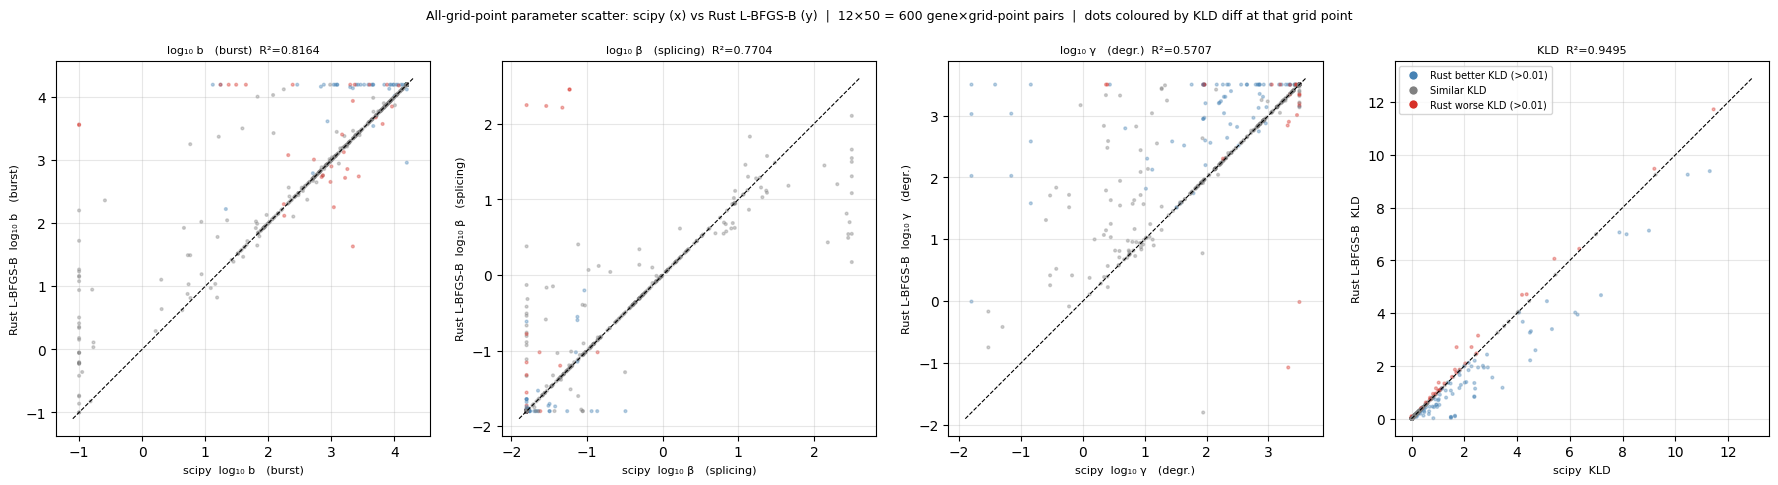

Saved figures/rusty_vs_main_allgp_scatter.png


In [8]:
# ── All-grid-point parameter scatter: scipy vs Rust L-BFGS-B ─────────────────
# Each dot = one (gene, grid-point) pair — n_gp_opt × N_OPT_GENES total.
# Coloured by KLD diff at that specific grid point (same scale as phys_optimum).
# Complements the contingency analysis above; shows where in parameter space
# the two optimizers agree and where they diverge.

# Flatten: (n_gp, n_genes, 3) → (n_gp*n_genes, 3)
p_sc_flat = p_sc.reshape(-1, 3)
p_ru_flat = p_ru.reshape(-1, 3)
kd_flat   = kld_diff.ravel()   # (n_gp*n_genes,)

c_flat = np.where(kd_flat < -KLD_T, C_RUST,
         np.where(kd_flat >  KLD_T, C_SERIAL, 'grey'))

param_names_gp  = ['log\u2081\u2080 b\u2003(burst)', 'log\u2081\u2080 \u03b2\u2003(splicing)', 'log\u2081\u2080 \u03b3\u2003(degr.)']
param_colors_gp = ['#2166ac', '#4dac26', '#d01c8b']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for pi, pname in enumerate(param_names_gp):
    ax = axes[pi]
    xv, yv = p_sc_flat[:, pi], p_ru_flat[:, pi]
    ax.scatter(xv, yv, c=c_flat, s=4, alpha=0.35, rasterized=True)
    lo = min(xv.min(), yv.min()) - 0.1
    hi = max(xv.max(), yv.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    r2 = float(np.corrcoef(xv, yv)[0, 1] ** 2)
    ax.set_xlabel(f'scipy  {pname}', fontsize=8)
    ax.set_ylabel(f'Rust L-BFGS-B  {pname}', fontsize=8)
    ax.set_title(f'{pname}  R\u00b2={r2:.4f}', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')

ax = axes[3]
ksc_flat = k_sc.ravel()
kru_flat = k_ru.ravel()
ax.scatter(ksc_flat, kru_flat, c=c_flat, s=4, alpha=0.35, rasterized=True)
lo = min(ksc_flat.min(), kru_flat.min()) * 0.9
hi = max(ksc_flat.max(), kru_flat.max()) * 1.1
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=C_RUST,   ms=7, label=f'Rust better KLD (>{KLD_T})'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='grey',   ms=7, label='Similar KLD'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=C_SERIAL, ms=7, label=f'Rust worse KLD (>{KLD_T})'),
], fontsize=7)
r2_kld = float(np.corrcoef(ksc_flat, kru_flat)[0, 1] ** 2)
ax.set_xlabel('scipy  KLD', fontsize=8)
ax.set_ylabel('Rust L-BFGS-B  KLD', fontsize=8)
ax.set_title(f'KLD  R\u00b2={r2_kld:.4f}', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', 'box')

plt.suptitle(
    f'All-grid-point parameter scatter: scipy (x) vs Rust L-BFGS-B (y)  |  '
    f'{n_gp_opt}\u00d7{N_OPT_GENES} = {n_gp_opt * N_OPT_GENES} gene\u00d7grid-point pairs  |  '
    f'dots coloured by KLD diff at that grid point',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_allgp_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_allgp_scatter.png')


### Optimizer result concordance scatter

Same scatter-plot style as the data-path concordance above, but now holding the **data path fixed** (Rust ) and varying the **optimizer**.  Each dot is one gene; colour shows which optimizer reached the lower KLD at the final (sampling-optimum) parameter estimate.

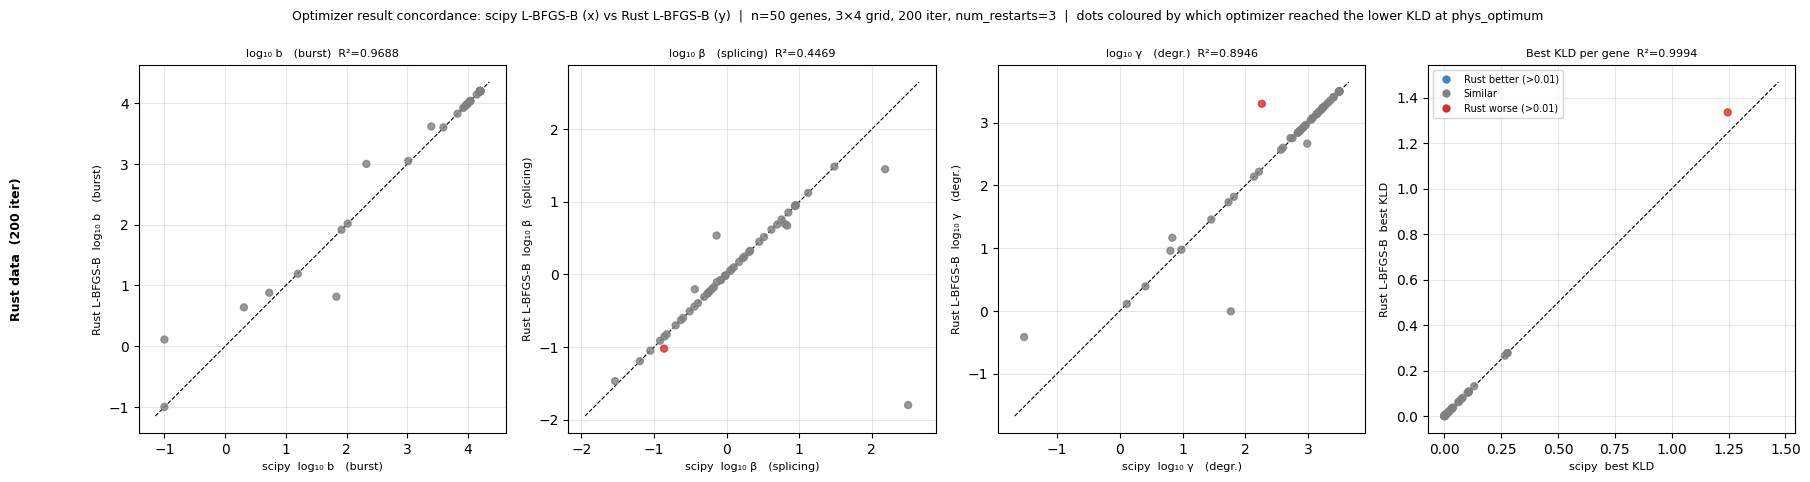

Saved figures/rusty_vs_main_opt_scatter.png
R² — b:0.9688  β:0.4469  γ:0.8946  KLD:0.9994


In [9]:
# ── Optimizer result concordance: same scatter style as data-path concordance ─────
# Reuses p_sc, p_ru, k_sc_best, k_ru_best from the cell above.
# x-axis = scipy L-BFGS-B result, y-axis = Rust L-BFGS-B result (same Rust data).
# For a perfect optimizer, all points should lie on the y=x diagonal.
phys_sc_opt = p_sc[k_sc.argmin(axis=0), np.arange(n_gene_opt), :]   # (n_genes, 3)
phys_ru_opt = p_ru[k_ru.argmin(axis=0), np.arange(n_gene_opt), :]

param_names_conc  = ['log\u2081\u2080 b\u2003(burst)', 'log\u2081\u2080 \u03b2\u2003(splicing)', 'log\u2081\u2080 \u03b3\u2003(degr.)']
param_colors_conc = ['#2166ac', '#4dac26', '#d01c8b']

def _scatter_opt_row(axes, x_params, y_params, x_klds, y_klds, x_label, y_label):
    delta_kld = y_klds - x_klds
    c_pts = np.where(delta_kld < -KLD_T, C_RUST,
            np.where(delta_kld >  KLD_T, C_SERIAL, 'grey'))
    for pi, (pname, color) in enumerate(zip(param_names_conc, param_colors_conc)):
        ax = axes[pi]
        xv, yv = x_params[:, pi], y_params[:, pi]
        ax.scatter(xv, yv, c=c_pts, s=25, alpha=0.8, zorder=3)
        lo = min(xv.min(), yv.min()) - 0.15
        hi = max(xv.max(), yv.max()) + 0.15
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
        r2 = float(np.corrcoef(xv, yv)[0, 1] ** 2)
        ax.set_xlabel(f'{x_label}  {pname}', fontsize=8)
        ax.set_ylabel(f'{y_label}  {pname}', fontsize=8)
        ax.set_title(f'{pname}  R\u00b2={r2:.4f}', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', 'box')
    ax = axes[3]
    ax.scatter(x_klds, y_klds, c=c_pts, s=25, alpha=0.8, zorder=3)
    lo = min(x_klds.min(), y_klds.min()) * 0.9
    hi = max(x_klds.max(), y_klds.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor=C_RUST,   ms=7, label=f'Rust better (>{KLD_T})'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='grey',   ms=7, label='Similar'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor=C_SERIAL, ms=7, label=f'Rust worse (>{KLD_T})'),
    ], fontsize=7)
    r2_kld = float(np.corrcoef(x_klds, y_klds)[0, 1] ** 2)
    ax.set_xlabel(f'{x_label}  best KLD', fontsize=8)
    ax.set_ylabel(f'{y_label}  best KLD', fontsize=8)
    ax.set_title(f'Best KLD per gene  R\u00b2={r2_kld:.4f}', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

_scatter_opt_row(
    axes,
    phys_sc_opt, phys_ru_opt,
    k_sc_best,   k_ru_best,
    x_label='scipy',
    y_label='Rust L-BFGS-B',
)

axes[0].annotate(
    f'Rust data  ({N_OPT_ITER} iter)',
    xy=(-0.35, 0.5), xycoords='axes fraction',
    fontsize=9, fontweight='bold', va='center', rotation=90,
)

plt.suptitle(
    f'Optimizer result concordance: scipy L-BFGS-B (x) vs Rust L-BFGS-B (y)  |  '
    f'n={N_OPT_GENES} genes, {GRIDSIZE[0]}\u00d7{GRIDSIZE[1]} grid, {N_OPT_ITER} iter, num_restarts={N_RESTARTS_OPT}  |  '
    f'dots coloured by which optimizer reached the lower KLD at phys_optimum',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_opt_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_opt_scatter.png')

r2_params = [float(np.corrcoef(phys_sc_opt[:,pi], phys_ru_opt[:,pi])[0,1]**2) for pi in range(3)]
r2_kld    = float(np.corrcoef(k_sc_best, k_ru_best)[0,1]**2)
print(f'R\u00b2 \u2014 b:{r2_params[0]:.4f}  \u03b2:{r2_params[1]:.4f}  \u03b3:{r2_params[2]:.4f}  KLD:{r2_kld:.4f}')


### Parameter-level breakdown of large diffs

The 32% large-diff rate hides important structure.  Three questions:

1. **Which parameter** (`b`, `β`, `γ`) drives the disagreements — or is it random?
2. **Are diffs small-but-numerous or large-and-rare?** — the histogram shape
   distinguishes optimizer noise from genuine local-minimum mismatches.
3. **Do disagreements cluster on specific genes or specific grid points?**
   — a gene-clustered pattern points to non-convex landscapes on those genes;
   a grid-point-clustered pattern points to a regime where one optimizer is
   systematically weaker.

Per-parameter: fraction of 600 pairs with |Δ| > 0.1:
  b  (burst freq): 21.7%
  β  (splicing): 18.0%
  γ  (degr.): 25.5%
  (any param):  32.0%

Per-gene disagree rate (frac of 12 gp with |Δmax|>0.1):
  mean=0.32  median=0.21  max=1.00  genes with rate>0.5: 12

Per-grid-point disagree rate (frac of 50 genes with |Δmax|>0.1):
  gp  0: 0.12
  gp  1: 0.60
  gp  2: 0.50
  gp  3: 0.44
  gp  4: 0.28
  gp  5: 0.32
  gp  6: 0.36
  gp  7: 0.32
  gp  8: 0.16
  gp  9: 0.14
  gp 10: 0.24
  gp 11: 0.36


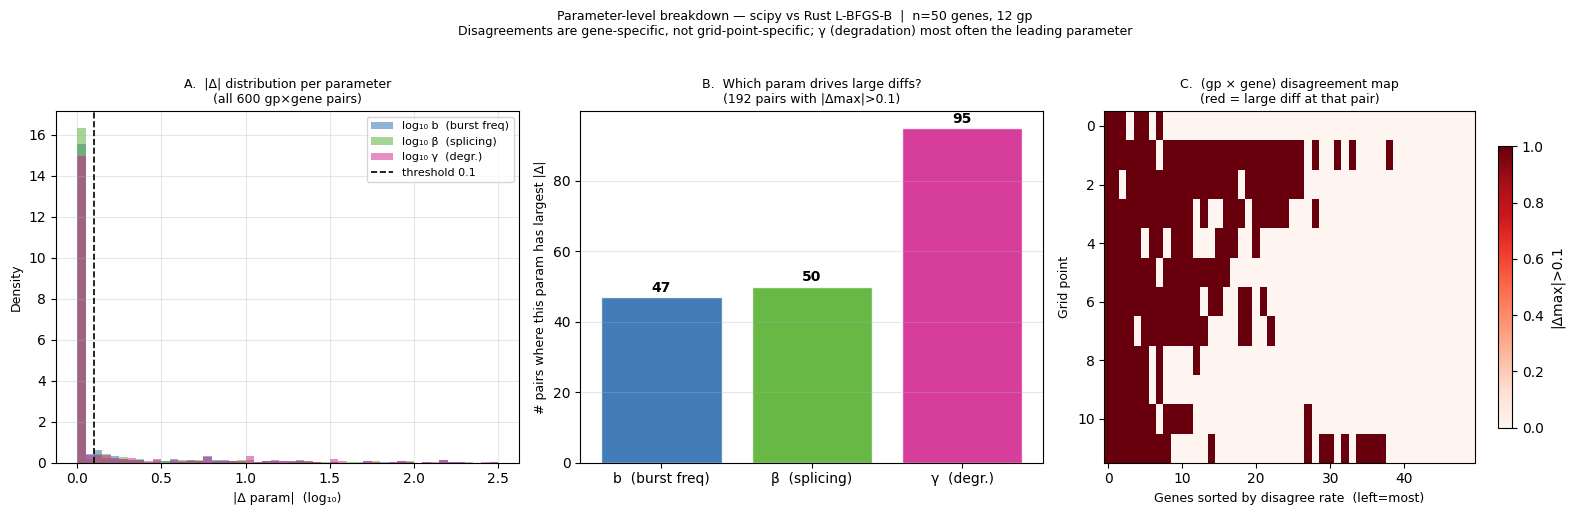

Saved figures/rusty_vs_main_param_breakdown.png


In [10]:
# ── Per-parameter breakdown ───────────────────────────────────────────────
# pdiff_3[gp, gene, param] = |scipy_param - rust_param| for each of the 3 params
pdiff_3 = np.abs(p_sc - p_ru)   # (n_gp, n_genes, 3)
param_names_short = ['b  (burst freq)', 'β  (splicing)', 'γ  (degr.)']
param_names_full  = ['log₁₀ b  (burst freq)', 'log₁₀ β  (splicing)', 'log₁₀ γ  (degr.)']
param_colors_3    = ['#2166ac', '#4dac26', '#d01c8b']

# For each large-diff pair, which param is the worst offender?
leading_param  = pdiff_3.argmax(axis=2)          # (n_gp, n_genes) → 0/1/2
large_mask_flat = max_pdiff.ravel() > PDIFF_T    # (600,)
leading_large  = leading_param.ravel()[large_mask_flat]

# Fraction of gp where each gene disagrees (per-parameter and overall)
disagree_mat = (max_pdiff > PDIFF_T).astype(float)   # (n_gp, n_genes)
disagree_per_gene = disagree_mat.mean(0)              # (n_genes,)
disagree_per_gp   = disagree_mat.mean(1)              # (n_gp,)

print('Per-parameter: fraction of 600 pairs with |Δ| > 0.1:')
for pi, pname in enumerate(param_names_short):
    frac = (pdiff_3[:, :, pi].ravel() > PDIFF_T).mean()
    print(f'  {pname}: {frac:.1%}')
print(f'  (any param):  {large_mask_flat.mean():.1%}')

print(f'\nPer-gene disagree rate (frac of {n_gp_opt} gp with |Δmax|>0.1):')
print(f'  mean={disagree_per_gene.mean():.2f}  '
      f'median={np.median(disagree_per_gene):.2f}  '
      f'max={disagree_per_gene.max():.2f}  '
      f'genes with rate>0.5: {(disagree_per_gene>0.5).sum()}')

print(f'\nPer-grid-point disagree rate (frac of {N_OPT_GENES} genes with |Δmax|>0.1):')
for gp_i, dr in enumerate(disagree_per_gp):
    print(f'  gp {gp_i:2d}: {dr:.2f}')

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: |Δ| distribution per parameter (overlapping histograms)
ax = axes[0]
bins = np.linspace(0, 2.5, 51)
for pi, (pname, color) in enumerate(zip(param_names_full, param_colors_3)):
    ax.hist(pdiff_3[:, :, pi].ravel(), bins=bins,
            color=color, alpha=0.5, label=pname, density=True)
ax.axvline(PDIFF_T, color='k', lw=1.2, ls='--', label=f'threshold {PDIFF_T}')
ax.set_xlabel('|Δ param|  (log₁₀)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('A.  |Δ| distribution per parameter\n(all 600 gp×gene pairs)', fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel B: which parameter leads large-diff pairs?
ax = axes[1]
counts = np.bincount(leading_large, minlength=3)
bars = ax.bar(param_names_short, counts, color=param_colors_3, alpha=0.85, edgecolor='white')
for xi, c in enumerate(counts):
    ax.text(xi, c + 1.5, str(c), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel(f'# pairs where this param has largest |Δ|', fontsize=9)
ax.set_title(f'B.  Which param drives large diffs?\n({large_mask_flat.sum()} pairs with |Δmax|>{PDIFF_T})', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Panel C: (gene × gp) disagreement heatmap
ax = axes[2]
gene_order = disagree_per_gene.argsort()[::-1]   # sort genes by disagree rate desc
im = ax.imshow(disagree_mat[:, gene_order], aspect='auto', cmap='Reds',
               vmin=0, vmax=1, interpolation='nearest')
plt.colorbar(im, ax=ax, label='|Δmax|>0.1', shrink=0.8)
ax.set_xlabel(f'Genes sorted by disagree rate  (left=most)', fontsize=9)
ax.set_ylabel('Grid point', fontsize=9)
ax.set_title('C.  (gp × gene) disagreement map\n(red = large diff at that pair)', fontsize=9)

plt.suptitle(
    f'Parameter-level breakdown — scipy vs Rust L-BFGS-B  |  n={N_OPT_GENES} genes, {n_gp_opt} gp\n'
    f'Disagreements are gene-specific, not grid-point-specific; '
    f'γ (degradation) most often the leading parameter',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_param_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_param_breakdown.png')

## Concordance at the final (sampling-optimum) parameters

The per-grid-point analysis above measures disagreements across all 12 grid points.
In practice, `find_sampling_optimum` selects the single best-fitting grid point per
gene, so per-grid-point failures can cancel: a gene that loses at 3 grid points may
still win at the other 9.  The cell below repeats the classification at the level of
the **final reported parameters** to show how much aggregation matters.

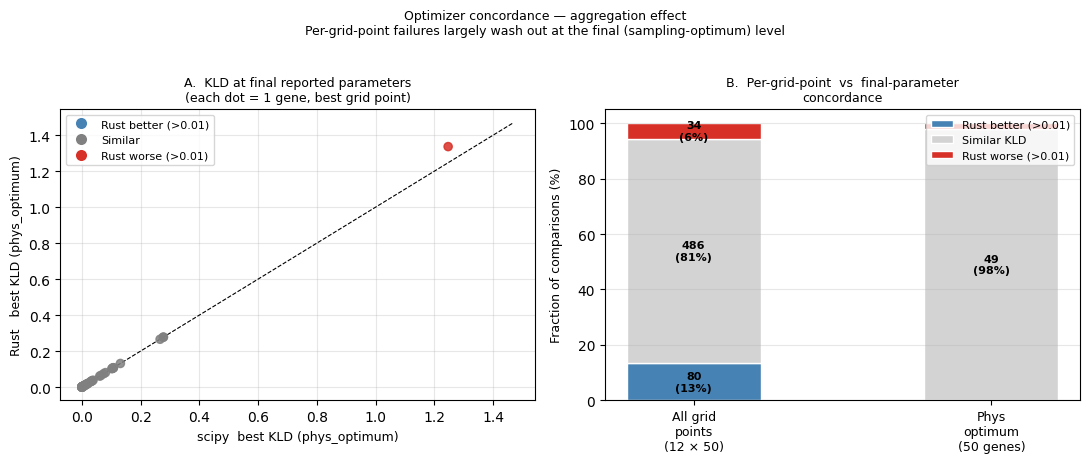

Saved figures/rusty_vs_main_opt_agg.png

Aggregation summary:
  Level            worse   better  similar
  All gp (n=600):   34 (6%)   80 (13%)  486 (81%)
  Phys opt (n=50):    1 (2%)    0 (0%)   49 (98%)

  KLD diff at phys_optimum: mean=0.002  (negative = net Rust advantage)
  Param diff (log10): 7/50 genes differ by >0.1 at phys_optimum


In [11]:
# Phys-optimum concordance: reuse p_sc, k_sc, p_ru, k_ru from the cell above.
# phys_optimum = params at the grid point with minimum KLD per gene.
best_gp_sc = k_sc.argmin(axis=0)                              # (n_genes,)
best_gp_ru = k_ru.argmin(axis=0)
phys_sc = p_sc[best_gp_sc, np.arange(n_gene_opt), :]          # (n_genes, n_params)
phys_ru = p_ru[best_gp_ru, np.arange(n_gene_opt), :]

kld_diff_opt  = k_ru_best - k_sc_best                         # (n_genes,)
pdiff_opt     = np.abs(phys_sc - phys_ru).max(axis=1)         # (n_genes,)
ruw_opt = kld_diff_opt >  KLD_T
rub_opt = kld_diff_opt < -KLD_T

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel A: KLD scatter at phys_optimum
ax = axes[0]
c_dot = np.where(kld_diff_opt < -KLD_T, C_RUST,
         np.where(kld_diff_opt >  KLD_T, C_SERIAL, 'grey'))
ax.scatter(k_sc_best, k_ru_best, c=c_dot, s=35, alpha=0.85, zorder=3)
lo = min(k_sc_best.min(), k_ru_best.min()) * 0.9
hi = max(k_sc_best.max(), k_ru_best.max()) * 1.1
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=C_RUST,  ms=9,label=f'Rust better (>{KLD_T})'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='grey',  ms=9,label='Similar'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=C_SERIAL,ms=9,label=f'Rust worse (>{KLD_T})'),
], fontsize=8)
ax.set_xlabel('scipy  best KLD (phys_optimum)', fontsize=9)
ax.set_ylabel('Rust   best KLD (phys_optimum)', fontsize=9)
ax.set_title('A.  KLD at final reported parameters\n(each dot = 1 gene, best grid point)', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: comparison bar — all gp vs phys_optimum
ax = axes[1]
levels  = ['All grid\npoints\n(12 × 50)', 'Phys\noptimum\n(50 genes)']
totals  = [n_gp_opt * N_OPT_GENES, N_OPT_GENES]
worse_n = [int((kld_diff >  KLD_T).sum()), int(ruw_opt.sum())]
better_n= [int((kld_diff < -KLD_T).sum()), int(rub_opt.sum())]
same_n  = [t - w - b for t, w, b in zip(totals, worse_n, better_n)]

x = np.array([0, 1])
b0 = np.zeros(2)
for vals, color, label in [
    (better_n, C_RUST,    f'Rust better (>{KLD_T})'),
    (same_n,   'lightgrey', f'Similar KLD'),
    (worse_n,  C_SERIAL,  f'Rust worse (>{KLD_T})'),
]:
    pct = [100*v/t for v, t in zip(vals, totals)]
    bars = ax.bar(x, pct, bottom=b0, color=color, width=0.45, label=label, edgecolor='white')
    for xi, (v, p, bot) in enumerate(zip(vals, pct, b0)):
        if p > 4:
            ax.text(xi, bot + p/2, f'{v}\n({p:.0f}%)', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    b0 = b0 + np.array(pct)

ax.set_xticks(x); ax.set_xticklabels(levels, fontsize=9)
ax.set_ylabel('Fraction of comparisons (%)', fontsize=9)
ax.set_ylim(0, 105)
ax.set_title('B.  Per-grid-point  vs  final-parameter\nconcordance', fontsize=9)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Optimizer concordance — aggregation effect\n'
    f'Per-grid-point failures largely wash out at the final (sampling-optimum) level',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_opt_agg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_opt_agg.png')

# ── Summary ───────────────────────────────────────────────────────────────
print(f'\nAggregation summary:')
print(f'  Level            worse   better  similar')
print(f'  All gp (n={n_gp_opt*N_OPT_GENES}):  '
      f'{(kld_diff>KLD_T).sum():3d} ({100*(kld_diff>KLD_T).mean():.0f}%)  '
      f'{(kld_diff<-KLD_T).sum():3d} ({100*(kld_diff<-KLD_T).mean():.0f}%)  '
      f'{(np.abs(kld_diff)<=KLD_T).sum():3d} ({100*(np.abs(kld_diff)<=KLD_T).mean():.0f}%)')
print(f'  Phys opt (n={N_OPT_GENES}):  '
      f'{ruw_opt.sum():3d} ({100*ruw_opt.mean():.0f}%)  '
      f'{rub_opt.sum():3d} ({100*rub_opt.mean():.0f}%)  '
      f'{(~ruw_opt&~rub_opt).sum():3d} ({100*(~ruw_opt&~rub_opt).mean():.0f}%)')
print(f'\n  KLD diff at phys_optimum: mean={kld_diff_opt.mean():.3f}  '
      f'(negative = net Rust advantage)')
print(f'  Param diff (log10): {(pdiff_opt>PDIFF_T).sum()}/{N_OPT_GENES} genes differ '
      f'by >{PDIFF_T} at phys_optimum')

## Expression level vs optimizer concordance

Does gene expression level predict *which* optimizer finds the better solution,
or how often they disagree?  Using the same 50-gene run from above:

- **KLD delta** = Rust best-KLD − scipy best-KLD per gene (negative = Rust better)
- **Disagree rate** = fraction of 12 grid points where |max param diff| > 0.1 log₁₀
- Expression metrics: mean spliced counts and per-cell detection rate

Spearman correlations:
  log10(mean spliced)      vs KLD delta         r=-0.247  p=0.084  
  log10(mean spliced)      vs disagree rate     r=+0.148  p=0.304  
  detection rate           vs KLD delta         r=-0.250  p=0.080  
  detection rate           vs disagree rate     r=+0.143  p=0.322  
  CV                       vs KLD delta         r=+0.253  p=0.076  
  CV                       vs disagree rate     r=-0.145  p=0.315  


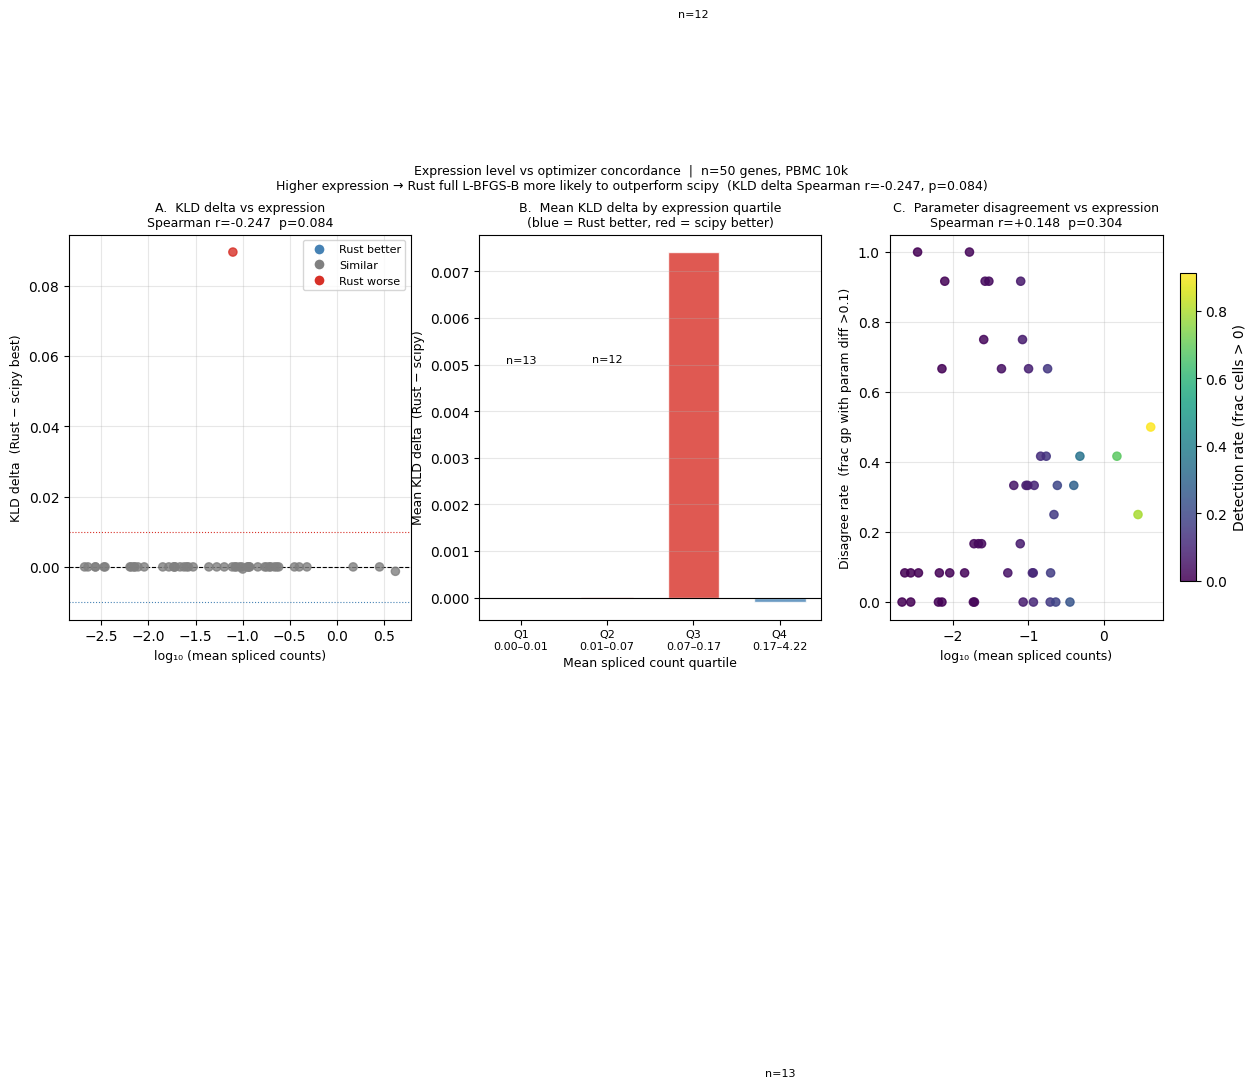

Saved figures/rusty_vs_main_expr_concordance.png


In [12]:
# Expression metrics for the N_OPT_GENES genes used in the optimizer concordance.
# Reuses p_sc, k_sc, p_ru, k_ru, delta, max_pdiff from the cell above.
import anndata as ad
import scipy.sparse as _ssp
from scipy.stats import spearmanr

_adata_expr = ad.read_h5ad(H5AD_PATH)
_var_names  = list(_adata_expr.var_names)
_gidx       = [_var_names.index(g) for g in GENES_OPT]

def _col(layer, idx):
    mat = _adata_expr.layers[layer]
    col = mat[:, idx]
    if _ssp.issparse(col): col = col.toarray()
    return np.asarray(col).ravel().astype(float)

mean_s = np.array([_col('spliced', i).mean()       for i in _gidx])
frac_s = np.array([(_col('spliced', i) > 0).mean() for i in _gidx])   # detection rate
std_s  = np.array([_col('spliced', i).std()        for i in _gidx])
cv_s   = std_s / np.maximum(mean_s, 1e-9)
del _adata_expr; gc.collect()

log_s        = np.log10(np.maximum(mean_s, 1e-3))
disagree_frac = (max_pdiff > PDIFF_T).mean(0)   # fraction of gp with large param diff

# ── Spearman correlations ─────────────────────────────────────────────────
print('Spearman correlations:')
corr_results = {}
for xname, xv in [('log10(mean spliced)', log_s), ('detection rate', frac_s), ('CV', cv_s)]:
    for yname, yv in [('KLD delta', delta), ('disagree rate', disagree_frac)]:
        rs, ps = spearmanr(xv, yv)
        corr_results[(xname, yname)] = (rs, ps)
        sig = '**' if ps < 0.01 else ('*' if ps < 0.05 else '')
        print(f'  {xname:<24} vs {yname:<16}  r={rs:+.3f}  p={ps:.3f}  {sig}')

# ── Quartile summary ─────────────────────────────────────────────────────
qs = np.nanpercentile(mean_s, [0, 25, 50, 75, 100])
q_labels, q_delta, q_disagree, q_n, q_midpoint = [], [], [], [], []
for q in range(4):
    mask = (mean_s >= qs[q]) & (mean_s <= qs[q+1] + 1e-9)
    q_labels.append(f'Q{q+1}\n{qs[q]:.2f}–{qs[q+1]:.2f}')
    q_delta.append(delta[mask].mean())
    q_disagree.append(disagree_frac[mask].mean())
    q_n.append(mask.sum())
    q_midpoint.append(mean_s[mask].mean())

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel A: KLD delta vs mean expression ────────────────────────────────
ax = axes[0]
c_pts = np.where(delta < -KLD_T, C_RUST, np.where(delta > KLD_T, C_SERIAL, 'grey'))
ax.scatter(log_s, delta, c=c_pts, s=35, alpha=0.8, zorder=3)
ax.axhline(0,      color='k',       lw=0.8, ls='--')
ax.axhline( KLD_T, color=C_SERIAL,  lw=0.8, ls=':')
ax.axhline(-KLD_T, color=C_RUST,    lw=0.8, ls=':')
# Annotate the big scipy failures
for gi, (ls_v, dv) in enumerate(zip(log_s, delta)):
    if dv < -0.05:
        ax.annotate(GENES_OPT[gi], (ls_v, dv),
                    textcoords='offset points', xytext=(5, 0), fontsize=7, alpha=0.8)
rs_kld, ps_kld = corr_results[('log10(mean spliced)', 'KLD delta')]
ax.set_xlabel('log₁₀ (mean spliced counts)', fontsize=9)
ax.set_ylabel('KLD delta  (Rust − scipy best)', fontsize=9)
ax.set_title(f'A.  KLD delta vs expression\nSpearman r={rs_kld:+.3f}  p={ps_kld:.3f}', fontsize=9)
ax.grid(True, alpha=0.3)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_RUST,   ms=8, label='Rust better'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',   ms=8, label='Similar'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_SERIAL, ms=8, label='Rust worse'),
], fontsize=8)

# ── Panel B: quartile summary bars ───────────────────────────────────────
ax = axes[1]
x = np.arange(4)
bar_colors = [C_RUST if d < 0 else C_SERIAL for d in q_delta]
bars = ax.bar(x, q_delta, color=bar_colors, alpha=0.8, width=0.6, edgecolor='white')
ax.axhline(0, color='k', lw=0.8)
for xi, (d, n) in enumerate(zip(q_delta, q_n)):
    yoff = -0.01 if d < 0 else 0.005
    ax.text(xi, d + yoff, f'n={n}', ha='center',
            va='top' if d < 0 else 'bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(q_labels, fontsize=8)
ax.set_xlabel('Mean spliced count quartile', fontsize=9)
ax.set_ylabel('Mean KLD delta  (Rust − scipy)', fontsize=9)
ax.set_title('B.  Mean KLD delta by expression quartile\n(blue = Rust better, red = scipy better)', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel C: disagree rate vs expression + detection ─────────────────────
ax = axes[2]
sc = ax.scatter(log_s, disagree_frac, c=frac_s, cmap='viridis', s=35, alpha=0.85,
                vmin=0, vmax=frac_s.max(), zorder=3)
plt.colorbar(sc, ax=ax, label='Detection rate (frac cells > 0)', shrink=0.8)
rs_dis, ps_dis = corr_results[('log10(mean spliced)', 'disagree rate')]
ax.set_xlabel('log₁₀ (mean spliced counts)', fontsize=9)
ax.set_ylabel('Disagree rate  (frac gp with param diff >0.1)', fontsize=9)
ax.set_title(f'C.  Parameter disagreement vs expression\nSpearman r={rs_dis:+.3f}  p={ps_dis:.3f}', fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Expression level vs optimizer concordance  |  n={N_OPT_GENES} genes, PBMC 10k\n'
    f'Higher expression → Rust full L-BFGS-B more likely to outperform scipy  '
    f'(KLD delta Spearman r={rs_kld:+.3f}, p={ps_kld:.3f})',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/rusty_vs_main_expr_concordance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/rusty_vs_main_expr_concordance.png')


## Speedup at [6, 7] grid (42 sampling points)

The default production grid (`[6, 7]` = 42 sampling-rate points) runs each gene
through 42 independent L-BFGS-B optimisations — 3.5× more than `[3, 4]`.  
Results below show how the rusty speedup scales with grid complexity,
capped at n=200 genes to keep the main-serial runtime under ~30 minutes.

In [13]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('/tmp/grid67_results.pkl', 'rb') as f:
    _d67 = pickle.load(f)
results_67 = _d67['results']
N_SWEEP_67 = _d67['N_SWEEP']
_n_cpu67   = _d67['n_cpu']

C_SERIAL = '#d73027'
C_RUST   = 'steelblue'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: absolute wall time, both grids ─────────────────────────────────
ax = axes[0]
# [3,4] results from main sweep
ms_34 = [results[('main_serial', n)][0] + results[('main_serial', n)][1] for n in N_SWEEP if n <= 200]
ru_34 = [results[('rusty_full',  n)][0] + results[('rusty_full',  n)][1] for n in N_SWEEP if n <= 200]
ns_34 = [n for n in N_SWEEP if n <= 200]
ms_67 = [results_67[('main_serial', n)][0] + results_67[('main_serial', n)][1] for n in N_SWEEP_67]
ru_67 = [results_67[('rusty_full',  n)][0] + results_67[('rusty_full',  n)][1] for n in N_SWEEP_67]

ax.plot(ns_34, ms_34, 'o-',  color=C_SERIAL, linewidth=2, label='main serial  [3×4]')
ax.plot(ns_34, ru_34, 's-',  color=C_RUST,   linewidth=2, label='rusty full   [3×4]')
ax.plot(N_SWEEP_67, ms_67, 'o--', color=C_SERIAL, linewidth=2, alpha=0.6, label='main serial  [6×7]')
ax.plot(N_SWEEP_67, ru_67, 's--', color=C_RUST,   linewidth=2, alpha=0.6, label='rusty full   [6×7]')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Wall time (ms)')
ax.set_title('Absolute wall time\nmain serial vs rusty full, both grids')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Right: speedup (rusty / main serial) for both grids ──────────────────
ax2 = axes[1]
sp_34 = [m / r for m, r in zip(ms_34, ru_34)]
sp_67 = [m / r for m, r in zip(ms_67, ru_67)]

ax2.plot(ns_34,     sp_34, 'o-',  color=C_RUST, linewidth=2.5, label='3×4 grid (12 pts)')
ax2.plot(N_SWEEP_67, sp_67, 's--', color=C_RUST, linewidth=2.5, alpha=0.7, label='6×7 grid (42 pts, default)')
for n, sp in zip(ns_34, sp_34):
    ax2.annotate(f'{sp:.1f}×', (n, sp), textcoords='offset points',
                 xytext=(0, 6), ha='center', fontsize=8, color=C_RUST)
for n, sp in zip(N_SWEEP_67, sp_67):
    ax2.annotate(f'{sp:.1f}×', (n, sp), textcoords='offset points',
                 xytext=(0, -14), ha='center', fontsize=8, color=C_RUST, alpha=0.8)
ax2.axhline(1, color='grey', linestyle=':', linewidth=1)
ax2.set_xlabel('Number of genes')
ax2.set_ylabel('Speedup over main serial')
ax2.set_title('Speedup vs main branch\nby grid size (PBMC 10k, Bursty+Poisson)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/rusty_vs_main_grid_comparison.png', dpi=150)
plt.show()
print('Saved figures/rusty_vs_main_grid_comparison.png')


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/grid67_results.pkl'